In [2]:
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 24.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from pymongo import MongoClient
import os
from dotenv import load_dotenv

# 🔹 Paste your MongoDB Atlas URI here

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")
# Connect to MongoDB

client = MongoClient(MONGO_URI)
db = client["aqi_project"]
# Select database and collection

collection = db["raw_data"]

# Fetch all documents
data = list(collection.find({}))

# Convert to DataFrame
df = pd.DataFrame(data)
df = df.sort_values("timestamp")
# Remove MongoDB internal column
if "_id" in df.columns:
    df.drop(columns=["_id"], inplace=True)

# Convert timestamp properly (important)
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

print("✅ Data Loaded Successfully")
print("Shape:", df.shape)
df.head()

✅ Data Loaded Successfully
Shape: (2184, 17)


,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,timestamp,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,wind_direction_10m,precipitation,cloud_cover,city,latitude,longitude
0,96.6,92.7,1124.0,39.4,14.7,42.0,2025-11-14 00:00:00,12.9,78,989.4,3.6,45,0.0,0,Gujrat,32.5731,74.1005
1,99.0,94.8,918.0,42.6,14.9,33.0,2025-11-14 01:00:00,12.1,84,989.0,5.2,49,0.0,0,Gujrat,32.5731,74.1005
2,97.1,92.9,761.0,44.6,14.5,25.0,2025-11-14 02:00:00,11.6,87,988.9,5.2,46,0.0,0,Gujrat,32.5731,74.1005
3,92.4,88.7,709.0,45.1,13.0,17.0,2025-11-14 03:00:00,10.9,89,988.5,4.0,36,0.0,0,Gujrat,32.5731,74.1005
4,87.1,83.8,706.0,44.3,10.9,11.0,2025-11-14 04:00:00,10.6,88,988.2,2.1,15,0.0,0,Gujrat,32.5731,74.1005


<h1><b>Data Exploration</b></h1>

In [21]:
print("Min:", df["timestamp"].min())
print("Max:", df["timestamp"].max())

Min: 2025-11-14 00:00:00
Max: 2026-02-12 23:00:00


In [4]:
total_hours = (df["timestamp"].max() - df["timestamp"].min()).total_seconds() / 3600
print("Expected hours:", total_hours)
print("Actual rows:", len(df))

Expected hours: 2183.0
Actual rows: 2184


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2184 entries, 0 to 2183
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   pm10                  2184 non-null   float64       
 1   pm2_5                 2184 non-null   float64       
 2   carbon_monoxide       2184 non-null   float64       
 3   nitrogen_dioxide      2184 non-null   float64       
 4   sulphur_dioxide       2184 non-null   float64       
 5   ozone                 2184 non-null   float64       
 6   timestamp             2184 non-null   datetime64[ns]
 7   temperature_2m        2184 non-null   float64       
 8   relative_humidity_2m  2184 non-null   int64         
 9   surface_pressure      2184 non-null   float64       
 10  wind_speed_10m        2184 non-null   float64       
 11  wind_direction_10m    2184 non-null   int64         
 12  precipitation         2184 non-null   float64       
 13  cloud_cover       

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df.isnull().sum()

pm10                    0
pm2_5                   0
carbon_monoxide         0
nitrogen_dioxide        0
sulphur_dioxide         0
ozone                   0
timestamp               0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
wind_direction_10m      0
precipitation           0
cloud_cover             0
city                    0
latitude                0
longitude               0
dtype: int64

In [8]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

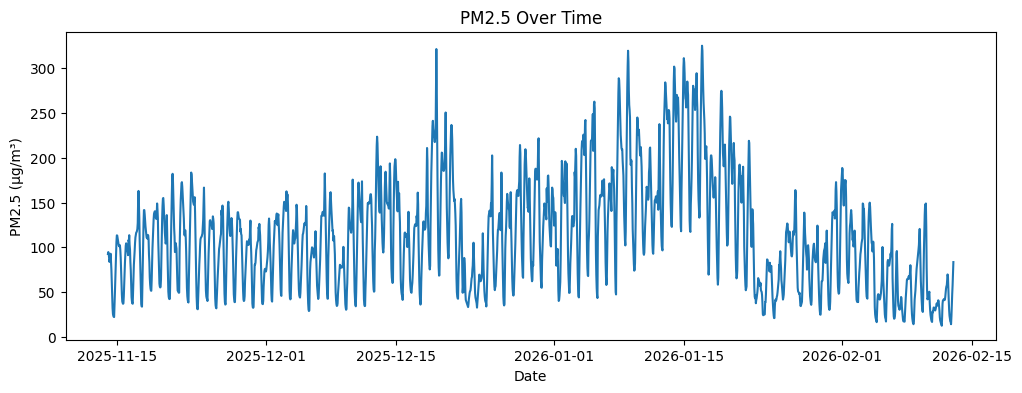

In [9]:
# Plot PM2.5 over time
plt.figure(figsize=(12, 4))
plt.plot(df['timestamp'], df['pm2_5'])
plt.title('PM2.5 Over Time')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

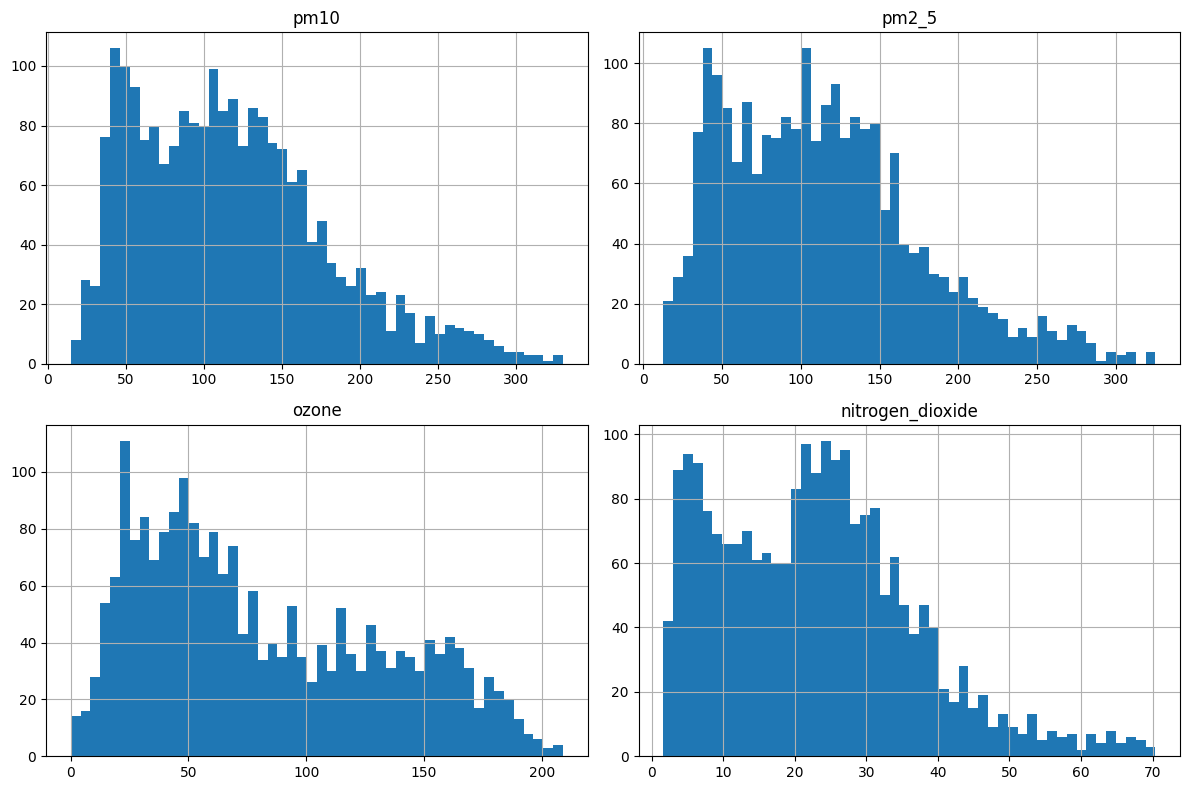

In [10]:
# Distribution of pollutants
df[['pm10', 'pm2_5', 'ozone', 'nitrogen_dioxide']].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

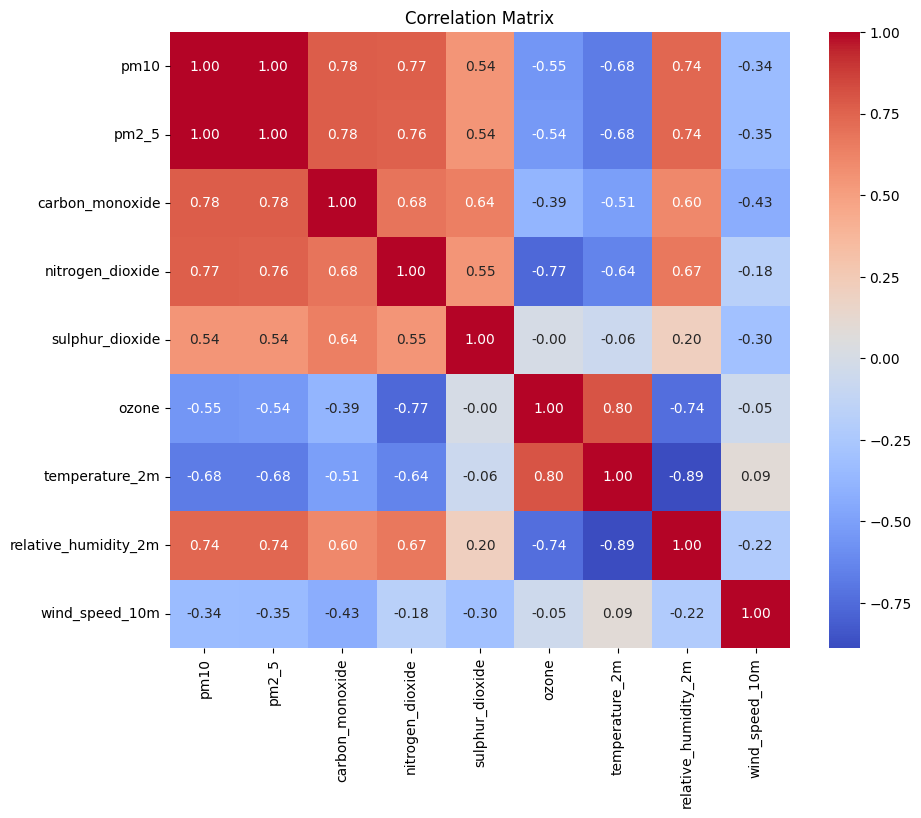

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
           'sulphur_dioxide', 'ozone', 'temperature_2m',
           'relative_humidity_2m', 'wind_speed_10m']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

<h1><b>AQI Calculation</b></h1>

In [12]:
import numpy as np

# 1. Define the aqi_breakpoints dictionary
# Note: Carbon monoxide (CO) breakpoints are converted from mg/m³ to µg/m³
# 1 mg/m³ = 1000 µg/m³
aqi_breakpoints = {
    'pm2_5': [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (251, 500, 401, 500)
    ],
    'pm10': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 1000, 401, 500)
    ],
    'ozone': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500) # Assuming an upper limit for calculation beyond 748
    ],
    'carbon_monoxide': [
        (0, 1000, 0, 50),     # 1 mg/m³ = 1000 µg/m³, so 1 mg/m³ breakpoint becomes 1000 µg/m³
        (1001, 2000, 51, 100),   # 2 mg/m³ = 2000 µg/m³
        (2001, 10000, 101, 200),  # 10 mg/m³ = 10000 µg/m³
        (10001, 17000, 201, 300), # 17 mg/m³ = 17000 µg/m³
        (17001, 34000, 301, 400), # 34 mg/m³ = 34000 µg/m³
        (34001, 50000, 401, 500)  # Assuming an upper limit for calculation beyond 34 mg/m³
    ],
    'sulphur_dioxide': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 2500, 401, 500) # Assuming an upper limit for calculation beyond 1600
    ],
    'nitrogen_dioxide': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 600, 401, 500) # Assuming an upper limit for calculation beyond 400
    ]
}

In [13]:
def calculate_aqi_for_pollutant(concentration, pollutant_name):
    # 3. Handle NaN concentrations
    if np.isnan(concentration):
        return None

    # 4. Retrieve breakpoints for the pollutant
    if pollutant_name not in aqi_breakpoints:
        raise ValueError(f"No AQI breakpoints found for pollutant: {pollutant_name}")

    breakpoints = aqi_breakpoints[pollutant_name]

    # 6. Handle cases where the concentration is below the lowest breakpoint
    if concentration <= breakpoints[0][1]: # C_high of the first interval
        return 0

    # Iterate through breakpoints to find the correct interval
    for i_low, i_high, bp_low, bp_high in breakpoints:
        if i_low <= concentration <= i_high:
            # 5. Implement linear interpolation
            aqi = ((bp_high - bp_low) / (i_high - i_low)) * (concentration - i_low) + bp_low
            # 7. Ensure that the calculated AQI is rounded to the nearest integer
            return int(round(aqi))

    # 8. For concentrations exceeding the highest defined breakpoint
    # If concentration is greater than the highest breakpoint in the list
    # use the last interval's slope and cap the AQI at 500.
    last_interval = breakpoints[-1]
    i_low_last, i_high_last, bp_low_last, bp_high_last = last_interval

    # Calculate AQI using the slope of the last interval
    # The formula remains the same, but the concentration is outside the defined range
    # We'll calculate it and then cap it.
    aqi = ((bp_high_last - bp_low_last) / (i_high_last - i_low_last)) * (concentration - i_low_last) + bp_low_last

    return int(round(min(aqi, 500))) # Cap AQI at 500

In [14]:
pollutant_columns = ['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

for pollutant in pollutant_columns:
    df[f'{pollutant}_aqi'] = df[pollutant].apply(lambda x: calculate_aqi_for_pollutant(x, pollutant))




In [15]:
aqi_columns = [f'{p}_aqi' for p in pollutant_columns]
df['overall_aqi'] = df[aqi_columns].max(axis=1)

print("Overall AQI calculated and added to the DataFrame.")
df.head()

Overall AQI calculated and added to the DataFrame.


,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,timestamp,temperature_2m,relative_humidity_2m,surface_pressure,...,city,latitude,longitude,pm2_5_aqi,pm10_aqi,carbon_monoxide_aqi,nitrogen_dioxide_aqi,sulphur_dioxide_aqi,ozone_aqi,overall_aqi
0,96.6,92.7,1124.0,39.4,14.7,42.0,2025-11-14 00:00:00,12.9,78,989.4,...,Gujrat,32.5731,74.1005,207,97,57,0,0,0,207
1,99.0,94.8,918.0,42.6,14.9,33.0,2025-11-14 01:00:00,12.1,84,989.0,...,Gujrat,32.5731,74.1005,214,99,0,53,0,0,214
2,97.1,92.9,761.0,44.6,14.5,25.0,2025-11-14 02:00:00,11.6,87,988.9,...,Gujrat,32.5731,74.1005,207,97,0,56,0,0,207
3,92.4,88.7,709.0,45.1,13.0,17.0,2025-11-14 03:00:00,10.9,89,988.5,...,Gujrat,32.5731,74.1005,196,92,0,56,0,0,196
4,87.1,83.8,706.0,44.3,10.9,11.0,2025-11-14 04:00:00,10.6,88,988.2,...,Gujrat,32.5731,74.1005,179,87,0,55,0,0,179


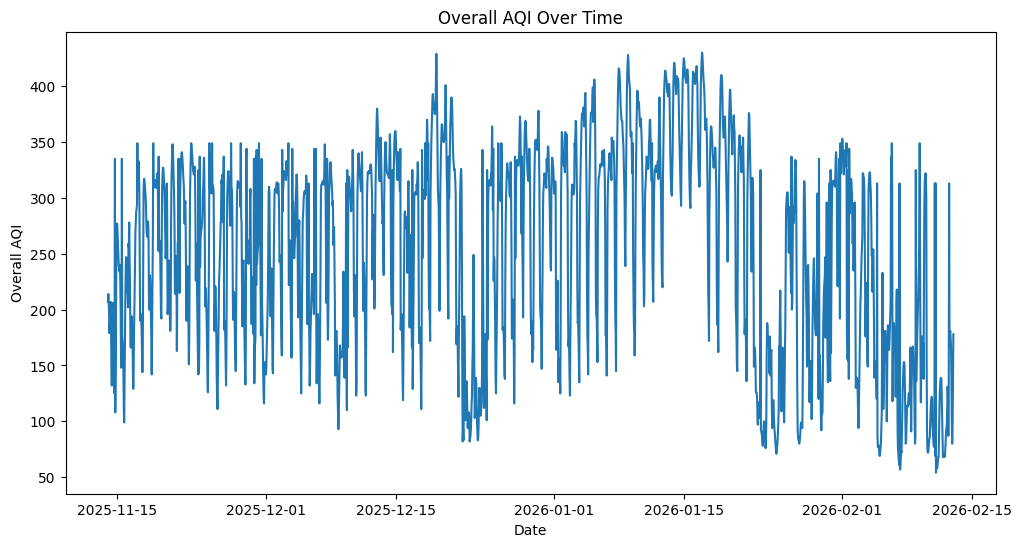

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['overall_aqi'])
plt.title('Overall AQI Over Time')
plt.xlabel('Date')
plt.ylabel('Overall AQI')
plt.show()

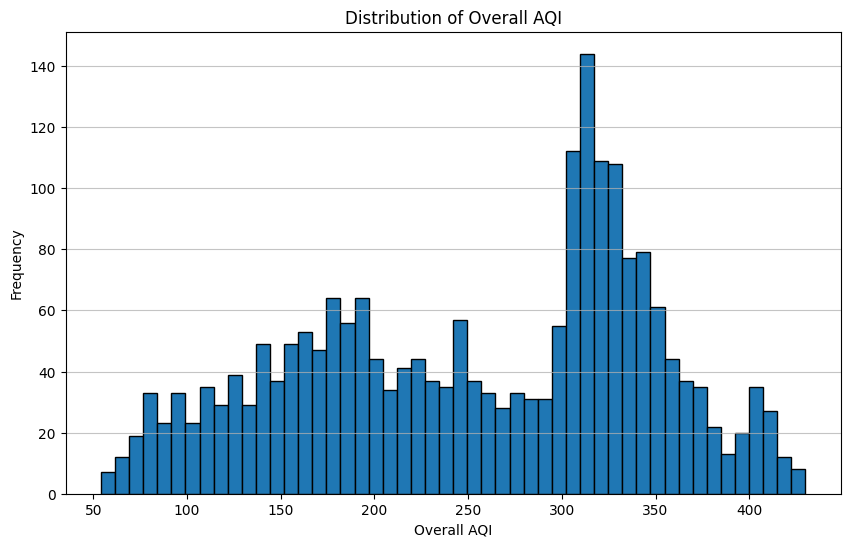

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df['overall_aqi'], bins=50, edgecolor='black')
plt.title('Distribution of Overall AQI')
plt.xlabel('Overall AQI')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [18]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek # Monday=0, Sunday=6
df['month'] = df['timestamp'].dt.month

print("Extracted 'hour_of_day', 'day_of_week', and 'month' from the timestamp column.")
display(df[['timestamp', 'hour_of_day', 'day_of_week', 'month']].head())

Extracted 'hour_of_day', 'day_of_week', and 'month' from the timestamp column.


,timestamp,hour_of_day,day_of_week,month
0,2025-11-14 00:00:00,0,4,11
1,2025-11-14 01:00:00,1,4,11
2,2025-11-14 02:00:00,2,4,11
3,2025-11-14 03:00:00,3,4,11
4,2025-11-14 04:00:00,4,4,11


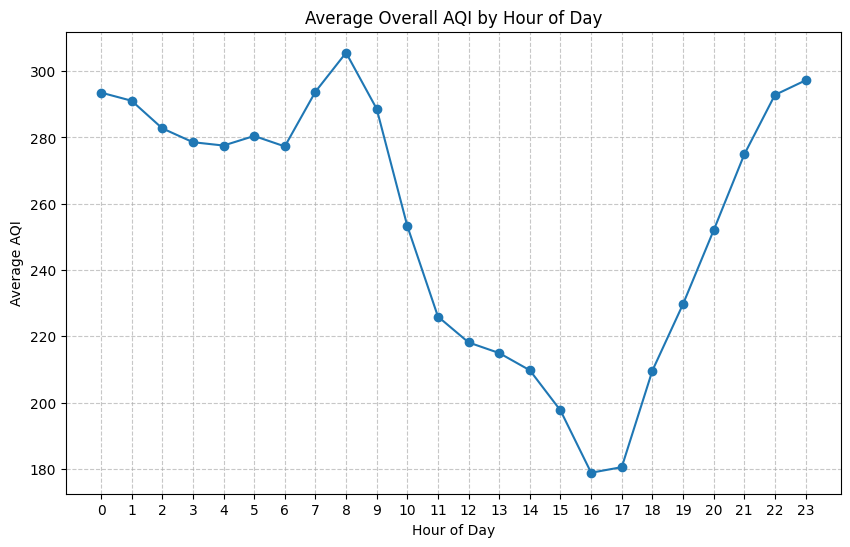

In [19]:
avg_aqi_by_hour = df.groupby('hour_of_day')['overall_aqi'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(avg_aqi_by_hour['hour_of_day'], avg_aqi_by_hour['overall_aqi'], marker='o')
plt.title('Average Overall AQI by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average AQI')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on the x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

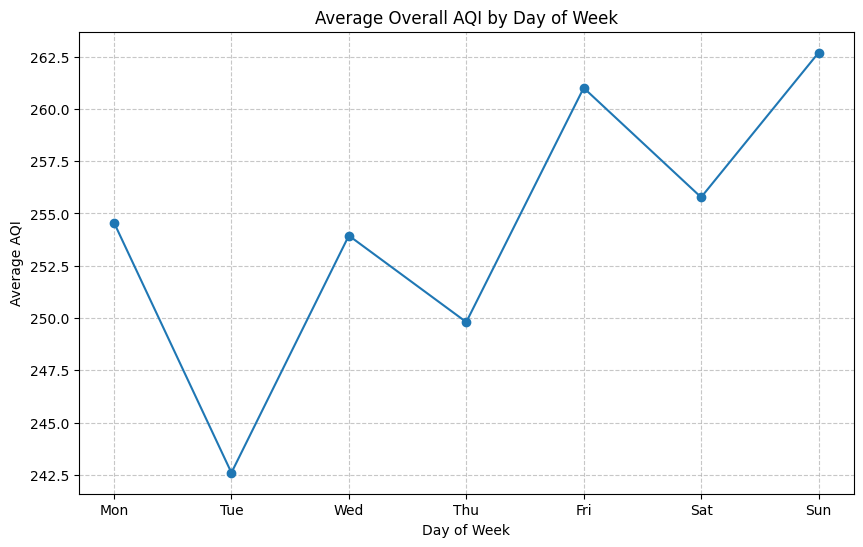

In [20]:
avg_aqi_by_day = df.groupby('day_of_week')['overall_aqi'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(avg_aqi_by_day['day_of_week'], avg_aqi_by_day['overall_aqi'], marker='o')
plt.title('Average Overall AQI by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average AQI')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']) # Label x-axis with days of the week
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()